In [2]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularPredictor
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(29)

In [3]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid1_firefox_onscreen.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid2_firefox_onscreen.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid3_firefox_onscreen.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid4_firefox_onscreen.csv")

In [4]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-4a_chrome_onscreen.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8a_chrome_onscreen.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8b_chrome_onscreen.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8c_chrome_onscreen.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8d_chrome_onscreen.csv")

In [5]:
df_rpi = pd.concat([rpi4a[:2000], rpi8a[:2000], rpi8b[:2000], rpi8c[:2000], rpi8d[:2000]])
df_odroid = pd.concat([odroid1[:2000], odroid2[:2000], odroid3[:2000], odroid4[:2000]])
df_rpi = df_rpi.sample(frac=1, random_state=29).reset_index(drop=True)
df_odroid = df_odroid.sample(frac=1, random_state=29).reset_index(drop=True)


<Axes: >

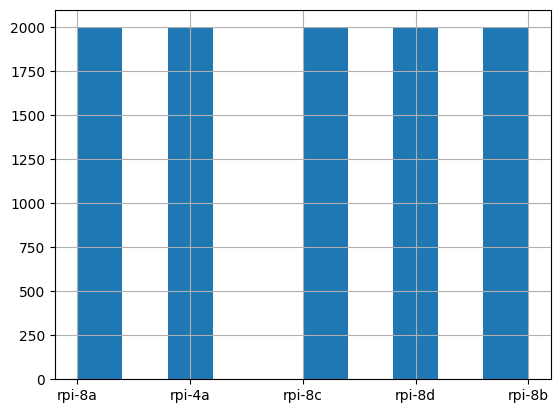

In [7]:
df_rpi['label'].hist()

<Axes: >

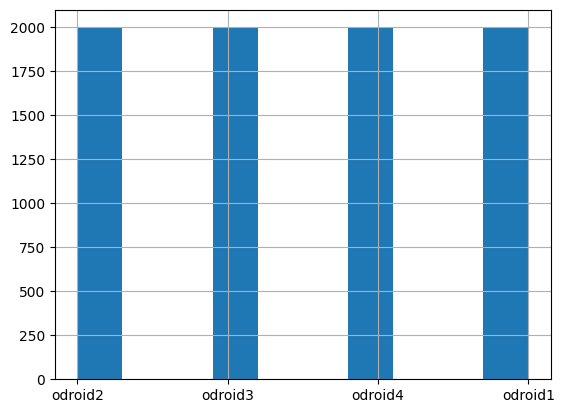

In [8]:
df_odroid['label'].hist()

# Whats the optimal amount of training data for Rpi?

In [11]:
stats_df = pd.DataFrame(columns=['data_amount', 'accuracy', 'balanced_accuracy', 'mcc'])

for i in range(1000, 8000, 1000):
    train_data = df_rpi.head(i)
    test_data = df_rpi.tail(3000)

    predictor = TabularPredictor(label='label', eval_metric='mcc').fit(train_data, num_gpus=1, presets='medium_quality', fit_weighted_ensemble=False)
    results = predictor.evaluate(test_data)

    new_row = {'data_amount': i, 'accuracy': results['accuracy'], 'balanced_accuracy':results['balanced_accuracy'], 'mcc':results['mcc']}
    stats_df.loc[len(stats_df)] = new_row

No path specified. Models will be saved in: "AutogluonModels\ag-20250418_022323"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       50.38 GB / 63.72 GB (79.1%)
Disk Space Avail:   910.22 GB / 1906.98 GB (47.7%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\zac\Documents\github\IoT-GPU-ID\5zkml_classification\AutogluonModels\ag-20250418_022323"
Train Data Rows:    1000
Train Data Columns: 7
Label Column:       label
AutoGluon infers your prediction problem is: 'multiclass' (because dtype of label-column == object).
	5 unique label values:  ['rpi-8a', 'rpi-4a', 'rpi-8c', 'rpi-8d', 'rpi-8b']
	If 'multiclass' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (Yo

[1000]	valid_set's multi_logloss: 0.547248	valid_set's mcc: 0.738308
[2000]	valid_set's multi_logloss: 0.679058	valid_set's mcc: 0.750695


	0.7538	 = Validation score   (mcc)
	30.4s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.7413	 = Validation score   (mcc)
	6.61s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.7197	 = Validation score   (mcc)
	0.42s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.7162	 = Validation score   (mcc)
	0.4s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.7236	 = Validation score   (mcc)
	0.39s	 = Training   run

In [12]:
stats_df

,data_amount,accuracy,balanced_accuracy,mcc
0,1000,0.713000,0.714428,0.641887
1,2000,0.776000,0.776949,0.720438
2,3000,0.790333,0.792016,0.739460
3,4000,0.821333,0.822286,0.776838
4,5000,0.811667,0.812564,0.764908
5,6000,0.825000,0.825975,0.781428
6,7000,0.827000,0.828072,0.783947


<Axes: xlabel='data_amount', ylabel='value'>

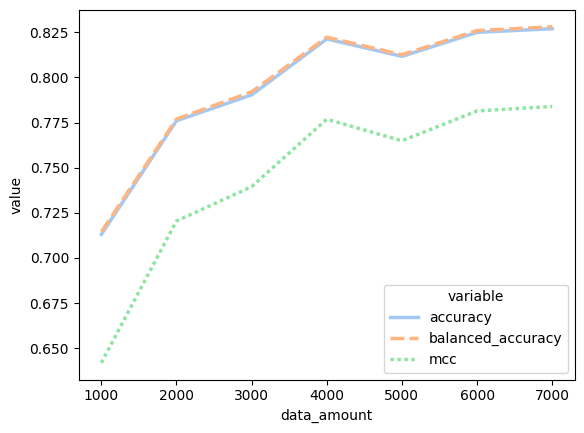

In [13]:
sns.lineplot(data=pd.melt(stats_df, ['data_amount']), x='data_amount', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

# 4000 Training rows for RPI

In [16]:
train_data = df_rpi.head(4000)
test_data = df_rpi.tail(6000)

predictor_rpi = TabularPredictor(label='label', eval_metric='mcc').fit(train_data, num_gpus=1, presets='medium_quality', fit_weighted_ensemble=False)
results = predictor.evaluate(test_data)
results

No path specified. Models will be saved in: "AutogluonModels\ag-20250418_024047"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       50.14 GB / 63.72 GB (78.7%)
Disk Space Avail:   908.46 GB / 1906.98 GB (47.6%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\zac\Documents\github\IoT-GPU-ID\5zkml_classification\AutogluonModels\ag-20250418_024047"
Train Data Rows:    4000
Train Data Columns: 7
Label Column:       label
AutoGluon infers your prediction problem is: 'multiclass' (because dtype of label-column == object).
	5 unique label values:  ['rpi-8a', 'rpi-4a', 'rpi-8c', 'rpi-8d', 'rpi-8b']
	If 'multiclass' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (Yo

{'mcc': np.float64(0.7664054085038557),
 'accuracy': 0.8128333333333333,
 'balanced_accuracy': np.float64(0.8129906588652883)}

In [17]:
predictor.leaderboard(test_data)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBMLarge,0.766405,0.790229,mcc,0.072908,0.018003,42.445022,0.072908,0.018003,42.445022,1,True,12
1,XGBoost,0.766057,0.787672,mcc,0.091298,0.019767,4.682901,0.091298,0.019767,4.682901,1,True,10
2,LightGBM,0.765161,0.790148,mcc,0.015584,0.006347,8.017524,0.015584,0.006347,8.017524,1,True,5
3,RandomForestGini,0.758389,0.778174,mcc,0.110003,0.043618,0.440674,0.110003,0.043618,0.440674,1,True,6
4,RandomForestEntr,0.756828,0.765483,mcc,0.082520,0.043855,0.457856,0.082520,0.043855,0.457856,1,True,7
5,ExtraTreesGini,0.752257,0.770937,mcc,0.097495,0.044735,0.406783,0.097495,0.044735,0.406783,1,True,8
6,ExtraTreesEntr,0.751521,0.771046,mcc,0.090508,0.043725,0.416273,0.090508,0.043725,0.416273,1,True,9
7,LightGBMXT,0.739769,0.760331,mcc,0.029042,0.007956,8.575467,0.029042,0.007956,8.575467,1,True,4
8,KNeighborsDist,0.693543,0.741300,mcc,0.064834,0.020695,0.004032,0.064834,0.020695,0.004032,1,True,2
9,NeuralNetTorch,0.669001,0.694615,mcc,0.022995,0.011290,9.498183,0.022995,0.011290,9.498183,1,True,11


# Best number of rows for odroid

In [18]:
stats_df = pd.DataFrame(columns=['data_amount', 'accuracy', 'balanced_accuracy', 'mcc'])

for i in range(1000, 8000, 1000):
    train_data = df_odroid.head(i)
    test_data = df_odroid.tail(3000)

    predictor = TabularPredictor(label='label', eval_metric='mcc').fit(train_data, num_gpus=1, presets='medium_quality', fit_weighted_ensemble=False)
    results = predictor.evaluate(test_data)

    new_row = {'data_amount': i, 'accuracy': results['accuracy'], 'balanced_accuracy':results['balanced_accuracy'], 'mcc':results['mcc']}
    stats_df.loc[len(stats_df)] = new_row

No path specified. Models will be saved in: "AutogluonModels\ag-20250418_024200"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       49.99 GB / 63.72 GB (78.5%)
Disk Space Avail:   908.26 GB / 1906.98 GB (47.6%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\zac\Documents\github\IoT-GPU-ID\5zkml_classification\AutogluonModels\ag-20250418_024200"
Train Data Rows:    1000
Train Data Columns: 7
Label Column:       label
AutoGluon infers your prediction problem is: 'multiclass' (because dtype of label-column == object).
	4 unique label values:  ['odroid2', 'odroid3', 'odroid4', 'odroid1']
	If 'multiclass' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may 

In [19]:
stats_df

,data_amount,accuracy,balanced_accuracy,mcc
0,1000,0.952000,0.951209,0.936032
1,2000,0.968333,0.967586,0.958031
2,3000,0.970667,0.969973,0.961081
3,4000,0.969333,0.968659,0.959134
4,5000,0.966667,0.966156,0.955548
5,6000,0.965333,0.964233,0.954251
6,7000,0.988667,0.988405,0.984883


# Best number is 3000

<Axes: xlabel='data_amount', ylabel='value'>

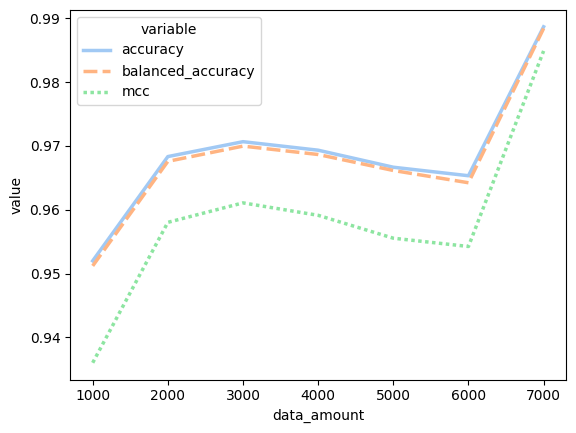

In [20]:
sns.lineplot(data=pd.melt(stats_df, ['data_amount']), x='data_amount', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

In [21]:

train_data = df_odroid.head(3000)
test_data = df_odroid.tail(7000)

predictor_odroid = TabularPredictor(label='label', eval_metric='mcc').fit(train_data, num_gpus=1, presets='medium_quality', fit_weighted_ensemble=False)
results = predictor.evaluate(test_data)
results

No path specified. Models will be saved in: "AutogluonModels\ag-20250418_025236"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       50.05 GB / 63.72 GB (78.5%)
Disk Space Avail:   907.72 GB / 1906.98 GB (47.6%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\zac\Documents\github\IoT-GPU-ID\5zkml_classification\AutogluonModels\ag-20250418_025236"
Train Data Rows:    3000
Train Data Columns: 7
Label Column:       label
AutoGluon infers your prediction problem is: 'multiclass' (because dtype of label-column == object).
	4 unique label values:  ['odroid2', 'odroid3', 'odroid4', 'odroid1']
	If 'multiclass' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may 

{'mcc': np.float64(0.9910475135957298),
 'accuracy': 0.9932857142857143,
 'balanced_accuracy': np.float64(0.9932922438863448)}

In [22]:
predictor_odroid.leaderboard(test_data)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,ExtraTreesGini,0.970158,0.952182,mcc,0.071692,0.043678,0.355443,0.071692,0.043678,0.355443,1,True,8
1,ExtraTreesEntr,0.969405,0.957498,mcc,0.070340,0.043924,0.360383,0.070340,0.043924,0.360383,1,True,9
2,LightGBMLarge,0.966886,0.946998,mcc,0.086481,0.007842,25.299463,0.086481,0.007842,25.299463,1,True,12
3,LightGBM,0.965735,0.954723,mcc,0.031938,0.009282,6.239292,0.031938,0.009282,6.239292,1,True,5
4,RandomForestEntr,0.965559,0.944263,mcc,0.069458,0.034100,0.382138,0.069458,0.034100,0.382138,1,True,7
5,RandomForestGini,0.965176,0.949442,mcc,0.086942,0.043893,0.383173,0.086942,0.043893,0.383173,1,True,6
6,XGBoost,0.963081,0.949442,mcc,0.108553,0.043076,4.691526,0.108553,0.043076,4.691526,1,True,10
7,KNeighborsDist,0.960473,0.938870,mcc,0.060970,0.029324,0.000000,0.060970,0.029324,0.000000,1,True,2
8,NeuralNetTorch,0.956617,0.949507,mcc,0.022614,0.000559,9.566175,0.022614,0.000559,9.566175,1,True,11
9,LightGBMXT,0.953884,0.946998,mcc,0.044380,0.013885,3.821641,0.044380,0.013885,3.821641,1,True,4


In [26]:
combined_test = pd.concat([df_rpi.tail(6000), df_odroid.tail(7000)])

In [ ]:
max_traces = 10

for traces_for_this_run in range(2, max_traces + 1):
    print(traces_for_this_run)
    auth_list = []

    # We want to cycle through traces grouped by node
    for node_label in list(combined_test['label'].unique()):
        print(node_label)
        
        genuine_training_data_by_node = combined_test.loc[combined_test['label'] == node_label]

        # Cycle through rows of genuine data from one particular node in groups of traces_for_this_run
        previous_df_chunk = 0
        for df_chunk_index in range(traces_for_this_run, len(genuine_training_data_by_node), traces_for_this_run):
            single_auth_attempt = {}
            single_auth_attempt['label'] = node_label

            # run rows through classification and impersonator models
            chunk_of_rows = genuine_training_data_by_node[previous_df_chunk:df_chunk_index]

            classification_prediction = []
            if node_label in  ['odroid2', 'odroid3', 'odroid4', 'odroid1']:
                classification_prediction = predictor_odroid.predict(chunk_of_rows, model='ExtraTreesGini')
            elif node_label in ['rpi-8a', 'rpi-4a', 'rpi-8c', 'rpi-8d', 'rpi-8b']:
                classification_prediction = predictor_rpi.predict(chunk_of_rows, model='LightGBMLarge')
            
            # Look at the classification results from both models, and decide if the result is match, mismatch, or impersonation.
            attempt_number = 0
            for single_classification_predicition in classification_prediction:
                print(single_classification_predicition)
                single_auth_attempt[f'attempt_{attempt_number}'] = single_classification_predicition
                attempt_number += 1
            

            auth_list.append(single_auth_attempt)
            previous_df_chunk = df_chunk_index

        authentication_attempts = pd.DataFrame(auth_list)
        authentication_attempts.to_csv(f'authentication_attempts_{traces_for_this_run}.csv')

2
rpi-4a
rpi-8a
rpi-8d
rpi-8c
rpi-8b
odroid2
odroid1
odroid4
odroid3
3
rpi-4a
rpi-8a
rpi-8d
rpi-8c
rpi-8b
odroid2
odroid1
odroid4
odroid3
4
rpi-4a
rpi-8a
rpi-8d
rpi-8c
rpi-8b
odroid2
odroid1
odroid4
odroid3
5
rpi-4a
rpi-8a
rpi-8d
rpi-8c
rpi-8b
odroid2
odroid1
odroid4
odroid3
6
rpi-4a
rpi-8a
rpi-8d
rpi-8c
rpi-8b
odroid2
odroid1
odroid4
odroid3
7
rpi-4a
rpi-8a
rpi-8d
rpi-8c
rpi-8b
odroid2
odroid1
odroid4
odroid3
8
rpi-4a
rpi-8a
rpi-8d
rpi-8c
rpi-8b
odroid2
odroid1
odroid4
odroid3
9
rpi-4a
rpi-8a
rpi-8d
rpi-8c
rpi-8b
odroid2
odroid1
odroid4
odroid3
10
rpi-4a
rpi-8a
rpi-8d
rpi-8c
rpi-8b
odroid2
odroid1
odroid4
odroid3


In [46]:
auth_attempts = 'auth_attempts\\authentication_attempts'


In [47]:
all_results = pd.DataFrame(columns=['traces_provided', 'accuracy', 'balanced_accuracy', 'mcc'])

max_traces = 10

for num_traces in range(2, max_traces+1, 1):
    print('---------------')
    print(num_traces)
    print('---------------')

    # Gather training data of matching number of traces
    auth_df = pd.read_csv(f'{auth_attempts}_{num_traces}.csv', index_col=[0])
    auth_df = auth_df.sample(frac=1)
    auth_df.reset_index(inplace=True, drop=True)

    train_auth = auth_df[:int(len(auth_df) * 0.75)]
    test_auth = auth_df[int(len(auth_df) * 0.75):]

    # Train an authenticator based on the number of traces
    # The validatation set used during trainind is really small, so accuracy look bad while training
    authenticator = TabularPredictor(label='label', eval_metric='mcc').fit(train_auth, num_gpus=1, presets='medium_quality', fit_weighted_ensemble=False)

    results = authenticator.evaluate(test_auth)

    new_results = {'traces_provided':num_traces, 'accuracy':results['accuracy'], 'balanced_accuracy':results['balanced_accuracy'], 'mcc':results['mcc']}
    all_results.loc[len(all_results)] = (new_results)

No path specified. Models will be saved in: "AutogluonModels\ag-20250418_050428"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       48.23 GB / 63.72 GB (75.7%)
Disk Space Avail:   907.23 GB / 1906.98 GB (47.6%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\zac\Documents\github\IoT-GPU-ID\5zkml_classification\AutogluonModels\ag-20250418_050428"
Train Data Rows:    4869
Train Data Columns: 2
Label Column:       label
AutoGluon infers your prediction problem is: 'multiclass' (because dtype of label-column == object).
	9 unique label values:  ['odroid4', 'rpi-8d', 'odroid2', 'odroid1', 'rpi-8b', 'rpi-8a', 'rpi-8c', 'odroid3', 'rpi-4a']
	If 'multiclass' is not the correct problem_type, please manually specify the prob

---------------
2
---------------


Fitting model: KNeighborsDist ...
	No valid features to train KNeighborsDist... Skipping this model.
Fitting model: NeuralNetFastAI ...
Metric mcc is not supported by this model - using log_loss instead
	0.9105	 = Validation score   (mcc)
	2.3s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: LightGBMXT ...
	Training LightGBMXT with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9192	 = Validation score   (mcc)
	2.07s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9172	 = Validation score   (mcc)
	2.31s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.9194	 = Validation score   (mcc)
	0.49s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9194	 = Validation score   (mcc)
	0.48s	 = Training   runtime
	0.04s	 = Vali

---------------
3
---------------


Fitting model: KNeighborsDist ...
	No valid features to train KNeighborsDist... Skipping this model.
Fitting model: NeuralNetFastAI ...
Metric mcc is not supported by this model - using log_loss instead
	0.964	 = Validation score   (mcc)
	1.43s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBMXT ...
	Training LightGBMXT with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9797	 = Validation score   (mcc)
	1.68s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9729	 = Validation score   (mcc)
	1.82s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.9707	 = Validation score   (mcc)
	0.49s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9729	 = Validation score   (mcc)
	0.46s	 = Training   runtime
	0.04s	 = Val

...

Fitting model: KNeighborsDist ...
	No valid features to train KNeighborsDist... Skipping this model.
Fitting model: NeuralNetFastAI ...
Metric mcc is not supported by this model - using log_loss instead
	0.9907	 = Validation score   (mcc)
	0.67s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: LightGBMXT ...
	Training LightGBMXT with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9954	 = Validation score   (mcc)
	1.35s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9861	 = Validation score   (mcc)
	1.33s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.9907	 = Validation score   (mcc)
	0.45s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9907	 = Validation score   (mcc)
	0.44s	 = Training   runtime
	0.03s	 = Val

---------------
9
---------------


Fitting model: KNeighborsDist ...
	No valid features to train KNeighborsDist... Skipping this model.
Fitting model: NeuralNetFastAI ...
Metric mcc is not supported by this model - using log_loss instead
	0.9844	 = Validation score   (mcc)
	0.68s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: LightGBMXT ...
	Training LightGBMXT with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9948	 = Validation score   (mcc)
	1.4s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9896	 = Validation score   (mcc)
	1.42s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.9739	 = Validation score   (mcc)
	0.45s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9739	 = Validation score   (mcc)
	0.44s	 = Training   runtime
	0.04s	 = Vali

---------------
10
---------------


Fitting model: KNeighborsDist ...
	No valid features to train KNeighborsDist... Skipping this model.
Fitting model: NeuralNetFastAI ...
Metric mcc is not supported by this model - using log_loss instead
	0.9827	 = Validation score   (mcc)
	0.68s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBMXT ...
	Training LightGBMXT with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9942	 = Validation score   (mcc)
	1.26s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9884	 = Validation score   (mcc)
	1.2s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.9885	 = Validation score   (mcc)
	0.46s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9942	 = Validation score   (mcc)
	0.44s	 = Training   runtime
	0.04s	 = Valid

In [48]:
all_results

,traces_provided,accuracy,balanced_accuracy,mcc
0,2,0.913177,0.898302,0.902784
1,3,0.952865,0.940704,0.946620
2,4,0.974106,0.970060,0.970785
3,5,0.970724,0.965371,0.966879
4,6,0.985213,0.979383,0.983316
5,7,0.980562,0.975766,0.978021
6,8,0.990123,0.986161,0.988821
7,9,0.991667,0.987744,0.990561
8,10,0.990741,0.985784,0.989486


# 8 Traces good for ZKML Auth model

<Axes: xlabel='traces_provided', ylabel='value'>

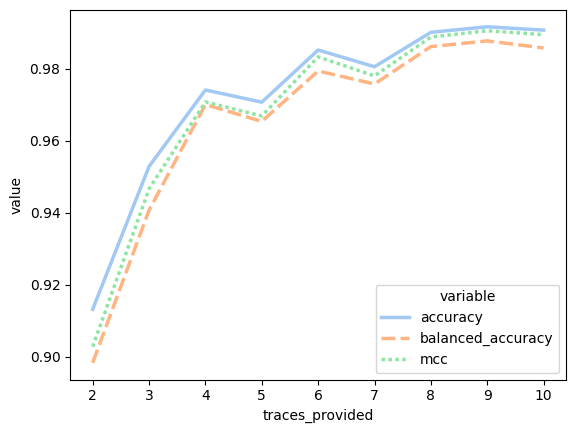

In [49]:
sns.lineplot(data=pd.melt(all_results, ['traces_provided']), x='traces_provided', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)